In [2]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score
import seaborn as sns
import numpy as np
import pandas as pd

In [3]:
from sklearn.datasets import fetch_openml
dataset = fetch_openml("mnist_784")
X = dataset["data"]
y = dataset["target"]

In [4]:
seed = 42
y = y.astype(int)

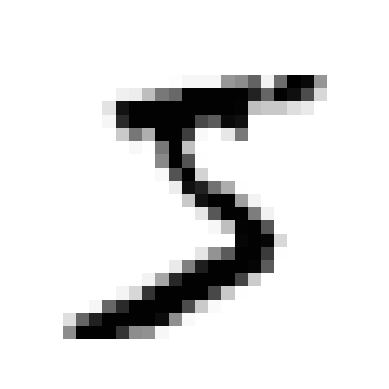

In [5]:
def show_digit(image_vector, label = None):
    # image_vector = np.array(image_vector)
    image_matrix = image_vector.reshape(28, 28)
    plt.imshow(image_matrix, cmap="Grays") # Grays para invertir colores
    # plt.title(f"Digito: {label}")
    plt.axis("off")
    plt.show()

for i in range(1):
    show_digit(np.array(X.iloc[i]))

In [6]:
X_small = X.iloc[0:2000]
y_small  = y[:2000]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_small, y_small, test_size=0.25, random_state=seed)

clf = DecisionTreeClassifier(random_state=seed)
clf.fit(X_train, y_train)
accuracy_clf = accuracy_score(y_test, clf.predict(X_test))

gb_clf = GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=seed)
gb_clf.fit(X_train, y_train)
accuracy_gb = accuracy_score(y_test, gb_clf.predict(X_test))

rf_clf = RandomForestClassifier(random_state=seed)
rf_clf.fit(X_train, y_train)
accuracy_rf  = accuracy_score(y_test, rf_clf.predict(X_test))

print(f"""
* Decision Tree:
    Accuracy: {accuracy_clf:.2f}

* Gradient Boosting:
    Accuracy: {accuracy_gb:.2f}

* Random Forest:
    Accuracy: {accuracy_rf:.2f}
""")


* Decision Tree:
    Accuracy: 0.72

* Gradient Boosting:
    Accuracy: 0.88

* Random Forest:
    Accuracy: 0.92



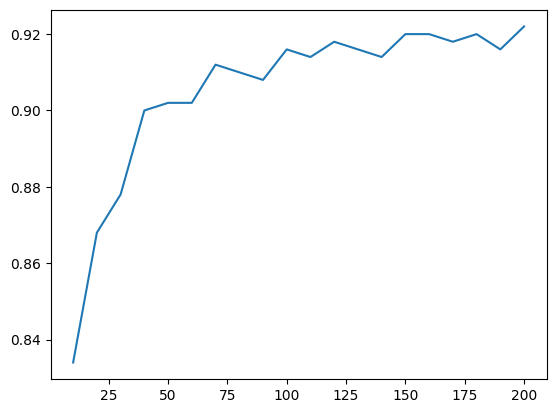

In [8]:
estimators = [i for i in range(10,201,10)]
accuracies = []

for estimator in estimators:
    rf_clf = RandomForestClassifier(n_estimators=estimator, random_state=seed)
    rf_clf.fit(X_train, y_train)
    accuracy_rf = accuracy_score(y_test, rf_clf.predict(X_test))
    accuracies.append(accuracy_rf)

plt.plot(estimators, accuracies)
plt.show()

<Axes: >

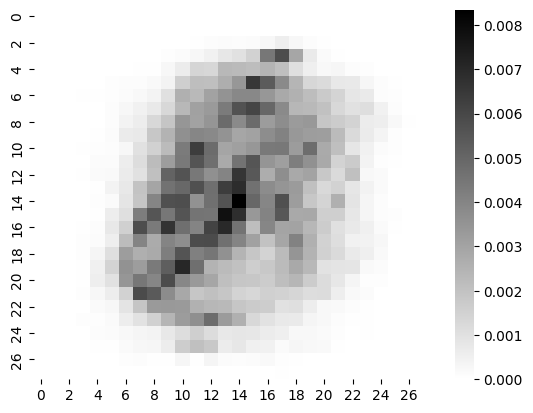

In [9]:
sns.heatmap(np.reshape(rf_clf.feature_importances_, (28, 28)), cmap='binary')

In [333]:
mask_01 = (y == 0) | (y == 1)
X_01 = X[mask_01]
y_01 = y[mask_01]

X_01

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69978,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69983,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69984,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69993,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


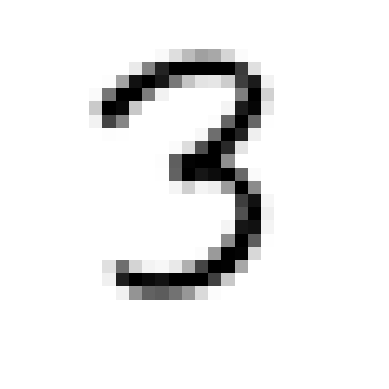

In [30]:
from PIL import Image
import os

path = os.path.join('number_3.jpg')

def cargar_imagen(path):
    img = Image.open(path).convert("L")
    img = img.resize((28, 28))
    img_array = np.array(img)
    if img_array.mean() > 127:
        img_array = 255 - img_array
    img_flat = img_array.reshape(1, -1)
    return img_flat, img_array

show_digit(cargar_imagen(path)[1])

X_3 = cargar_imagen(path)[0]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_small, y_small, test_size=0.25, random_state=seed)

rf_clf = RandomForestClassifier(random_state=seed)
rf_clf.fit(X_train, y_train)
print('Precisión:', accuracy_score(y_test, rf_clf.predict(X_test)))

rf_clf.predict(X_3)

Precisión: 0.916


c:\Users\rock-\Downloads\Facultad\Ciencia_de_Datos\.sklearn-env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([3])

Digito 0: 0.030
Digito 1: 0.020
Digito 2: 0.140
Digito 3: 0.420
Digito 4: 0.030
Digito 5: 0.150
Digito 6: 0.050
Digito 7: 0.060
Digito 8: 0.050
Digito 9: 0.050


c:\Users\rock-\Downloads\Facultad\Ciencia_de_Datos\.sklearn-env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


<BarContainer object of 10 artists>

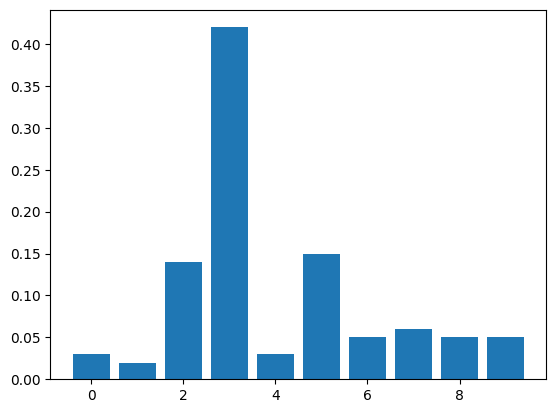

In [ ]:
probas = rf_clf.predict_proba(X_3)
for i, p in enumerate(probas[0]):
    print(f"Digito {i}: {p:.3f}")

plt.bar([i for i in range(10)],probas[0])

#### Tarea 8

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score
import seaborn as sns
import numpy as np
import pandas as pd

In [ ]:
from sklearn.datasets import fetch_openml
dataset = fetch_openml("mnist_784")
X = dataset["data"]
y = dataset["target"]

In [ ]:
seed = 42
y = y.astype(int)

(array([6903., 7877., 6990., 7141., 6824., 6313., 6876., 7293., 6825.,
        6958.]),
 array([0. , 0.9, 1.8, 2.7, 3.6, 4.5, 5.4, 6.3, 7.2, 8.1, 9. ]),
 <BarContainer object of 10 artists>)

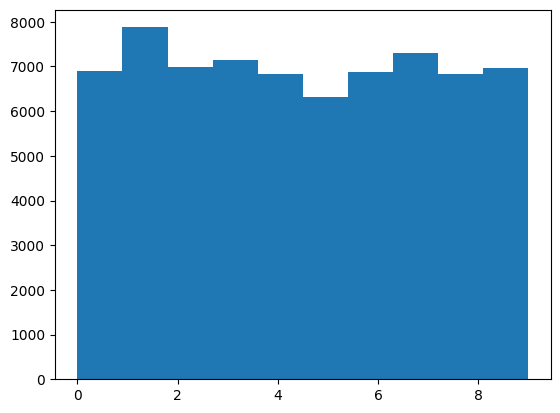

In [33]:
plt.hist(y)

(array([5920., 6725., 6023., 6107., 5918., 5376., 5915., 6238., 5856.,
        5922.]),
 array([0. , 0.9, 1.8, 2.7, 3.6, 4.5, 5.4, 6.3, 7.2, 8.1, 9. ]),
 <BarContainer object of 10 artists>)

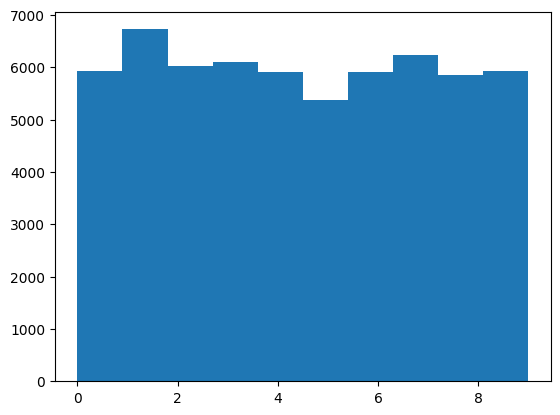

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/7, random_state=seed)

In [82]:
accuracies = []

max_trees = 500
tolerance = 0.0001

prev_acc = 0

for n in range(10, max_trees+1, 10):
    rf = RandomForestClassifier(n_estimators=n, n_jobs=-1, random_state=seed)
    rf.fit(X_train, y_train)
    acc = accuracy_score(y_test, rf.predict(X_test))
    accuracies.append(acc)

    if abs(acc - prev_acc) < tolerance:
        best_n = n
        break

    prev_acc = acc

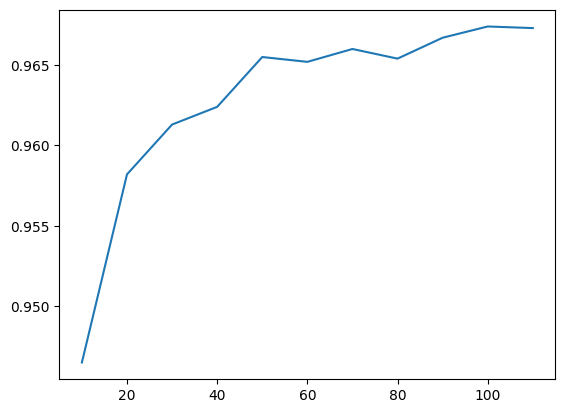

In [83]:
plt.plot([i for i in range(10, best_n+1, 10)], accuracies)
plt.show()

In [81]:
accuracies

[0.9465, 0.9613, 0.9655, 0.966, 0.9667, 0.9673, 0.9681, 0.9683, 0.9683]

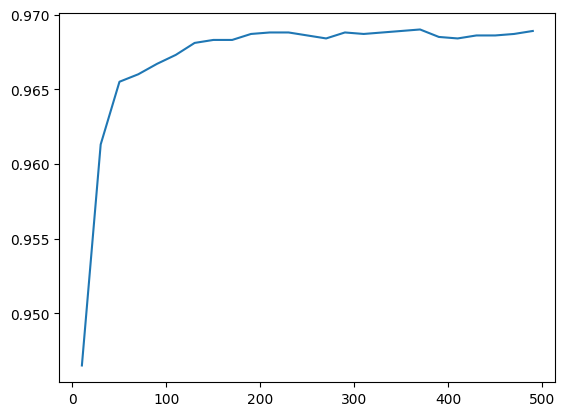

In [ ]:
# estimators = [i for i in range(10,501,20)]
# accuracies = []

# for estimator in estimators:
#     rf_clf = RandomForestClassifier(n_estimators=estimator, n_jobs=-1, random_state=seed)
#     rf_clf.fit(X_train, y_train)
#     accuracy_rf = accuracy_score(y_test, rf_clf.predict(X_test))
#     accuracies.append(accuracy_rf)

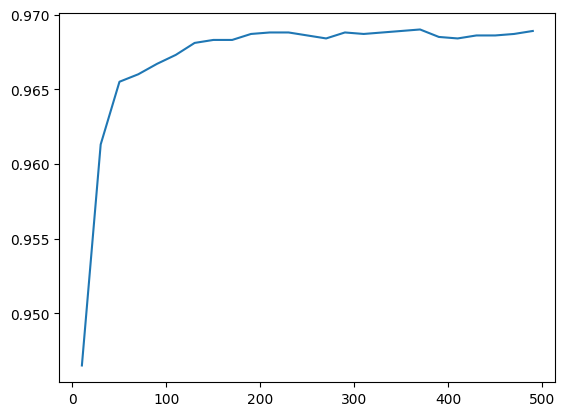

In [39]:
plt.plot(estimators, accuracies)
plt.show()

In [58]:
np.where(np.array(estimators)==210)
accuracies[10], accuracies[-1]
accuracies

[0.9465,
 0.9613,
 0.9655,
 0.966,
 0.9667,
 0.9673,
 0.9681,
 0.9683,
 0.9683,
 0.9687,
 0.9688,
 0.9688,
 0.9686,
 0.9684,
 0.9688,
 0.9687,
 0.9688,
 0.9689,
 0.969,
 0.9685,
 0.9684,
 0.9686,
 0.9686,
 0.9687,
 0.9689]

<Axes: >

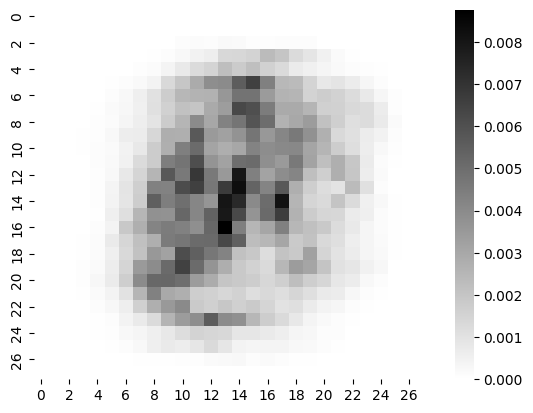

In [76]:
sns.heatmap(np.reshape(rf.feature_importances_, (28, 28)), cmap='binary')

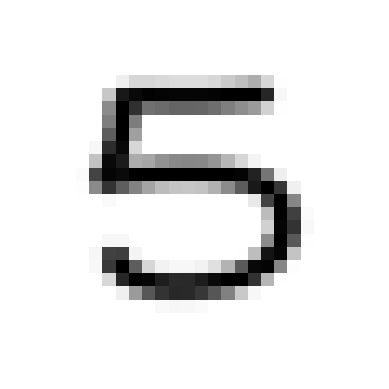

In [360]:
from PIL import Image
import os

path = os.path.join('j_5.jpg')

def cargar_imagen(path):
    img = Image.open(path).convert("L")
    img = img.resize((28, 28))
    img_array = np.array(img)
    if img_array.mean() > 127:
        img_array = 255 - img_array
    img_flat = img_array.reshape(1, -1)
    return img_flat, img_array

show_digit(cargar_imagen(path)[1])

X_3 = cargar_imagen(path)[0]

In [354]:
rf.predict(X_3)

c:\Users\rock-\Downloads\Facultad\Ciencia_de_Datos\.sklearn-env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([3])

Digito 0: 0.045
Digito 1: 0.000
Digito 2: 0.018
Digito 3: 0.155
Digito 4: 0.009
Digito 5: 0.627
Digito 6: 0.073
Digito 7: 0.018
Digito 8: 0.036
Digito 9: 0.018


c:\Users\rock-\Downloads\Facultad\Ciencia_de_Datos\.sklearn-env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


<BarContainer object of 10 artists>

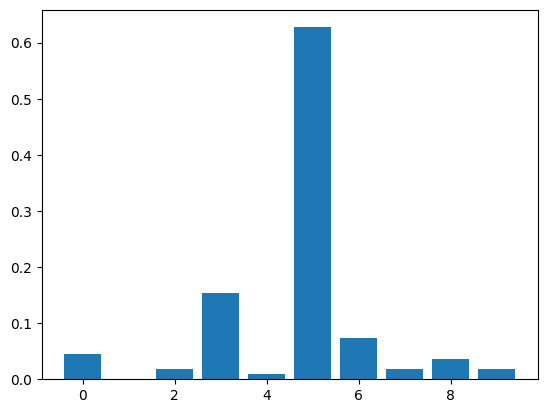

In [361]:
probas = rf.predict_proba(X_3)
for i, p in enumerate(probas[0]):
    print(f"Digito {i}: {p:.3f}")

plt.bar([i for i in range(10)],probas[0])